# plots

Avihay Cohen  
2025-04-24

In [ ]:
if (!requireNamespace("pacman", quietly = TRUE)) install.packages("pacman")
library(pacman)
pacman::p_load(tidyverse, DT, patchwork, RColorBrewer, here, tcltk, networkD3)

# Load _4 for counting with author overlap:

load(here("data", "wrangling_steps", "dcc_charite", "dcc_charite_joined_4_au_info.RData"))

# Load the most recent .RData file from the data\processed directory and assign it to "dcc_charite_joined_final"

# Assign the loaded object to a new variable name

load(here("data", "wrangling_steps", "dcc_charite", "dcc_charite_joined_7_covid_info.RData"))

dcc_charite_joined_final <- dcc_charite_joined_7_covid_info
rm(dcc_charite_joined_7_covid_info)

# Exclusion process of cases from the matched list

<br>

# Distinct Number of Papers and Datasets in Found in the DCC

<br>

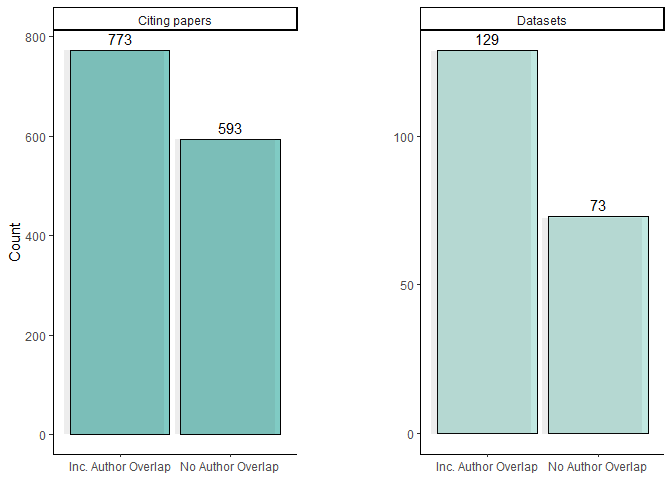

In [ ]:
#| label: fig-distinct-numbers
#| fig-cap: Distinct Number of Papers and Datasets in Found in the DCC
#| fig-format: png

# 1. Number of papers (dcc and charite) and of identifiers in final table (excluding author overlap cases)

counts_final <- tibble(
  `Citing papers` = dcc_charite_joined_final |> select(doi_dcc) |> distinct() |> nrow(),
  `Cited papers` = dcc_charite_joined_final |> select(doi_charite) |> distinct() |> nrow(),
  `Datasets` = dcc_charite_joined_final |> select(charite_data_id_or_acc_nr) |> distinct() |> nrow()
)

# 2. Number of papers (dcc and charite) and of identifiers in final table (including author overlap cases)

# I'll use dcc_charite_joined_4_au_info to count, since it is one step before excluding author overlap cases.

# However, I need to *exclude* cases where the author overlap is a result of the same paper that is present once as a preprint (as "doi_charite") and once as a publication (as "doi_dcc").

# So I'll first create a table with the cases suspected of being preprint-publication cases and check them for author overlap:

dcc_charite_blank_journals <- dcc_charite_joined_4_au_info |> # get all cases from the step before "author overlap exclusion" step
  dplyr::filter(journal == "") |> # get only cases where there's no journal information, because most of them are preprint cases
  rowwise()  |> 
  mutate(
    common_au = {
      common <- intersect(
        str_split(authors_dcc, ";")[[1]], 
        str_split(authors_charite, ";")[[1]]
      )
      if (length(common) > 0) paste(common, collapse = ";") else NA
    }
  ) |>
  ungroup() # check for author overlap in these cases only

# Then I'll verify that I should keep cases with partial overlap, since they are presumably cases of author overlap which are not a result of preprint-publication relation:

  # # Get partial overlap cases
  #
  # dcc_charite_blank_journals |>
  #   dplyr::filter(!is.na(common_au)) |> # remove cases where there's no overlap at all (they are irrelevant for this table in any case)
  #   dplyr::filter(authors_dcc != common_au) |> # remove cases where there's a full overlap
  #   ungroup() |>
  #   View()
  #
  # # I've checked each one manually and they are indeed not preprints - so they will be included in the "matched-with-author-overlap".

# Now I'll manually check the full (exact) overlap cases - these are suspected to be preprints:

dcc_charite_blank_journals_exact_overlap <- dcc_charite_blank_journals |>
  dplyr::filter(authors_dcc == common_au) |> # get cases with full overlap out of journal == ""
  select(doi_charite, doi_dcc) |>
  distinct()

# Results (distinct): 4 preprints, 2 datasets in doi_dcc(!). So those should be removed from "with-author-overlap".
# Note: they are already removed from the final matched list, because of the exact author overlap.

# Now I'll look for author overlap cases in general:

dcc_charite_all_exact_overlap <- dcc_charite_joined_4_au_info |> # get all cases from the step before "author overlap exclusion" step
  dplyr::filter(authors_dcc == authors_charite) |> 
  select(doi_charite, doi_dcc) |> 
  distinct()

# I've checked them manually as well, and they are also preprints-publications (10.1016/j.dib.2021.107320 is actually a data article under doi_dcc). So they should also be removed.

# Now I'll bind _all_exact_overlap cases with _blank_journals_exact_overlap cases, to create a table with preprint-publication cases to remove from matched-list-including-overlap

cases_to_remove <- dcc_charite_blank_journals_exact_overlap |> 
    bind_rows(dcc_charite_all_exact_overlap) |> 
  distinct()

# Remove those preprint-publication cases

dcc_charite_joined_w_au_ov <- dcc_charite_joined_4_au_info |> 
  anti_join(cases_to_remove, by = c("doi_charite", "doi_dcc")) 

# Get counts

counts_w_au_ov <- tibble(
  `Citing papers` = dcc_charite_joined_w_au_ov |> select(doi_dcc) |> distinct() |> nrow(),
  `Cited papers` = dcc_charite_joined_w_au_ov |> select(doi_charite) |> distinct() |> nrow(),
  `Datasets` = dcc_charite_joined_w_au_ov |> select(charite_data_id_or_acc_nr) |> distinct() |> nrow()
)

# Prepare count tibbles (with and without author overlap cases) for plotting

combined_count_tibbles <- counts_final |>
  bind_rows(counts_w_au_ov,
            .id = "tibble_source") |>
  select(-`Cited papers`) |> 
  mutate(tibble_source = recode(tibble_source,
                                "1" = "No Author Overlap",
                                "2" = "Inc. Author Overlap")) |> 
  pivot_longer(cols = -tibble_source, names_to = "variable", values_to = "value") |> 
  mutate(variable = fct_reorder(variable, value, .desc = TRUE))

# Plot

combined_count_tibbles |>
  ggplot(aes(x = tibble_source, y = value, fill = variable)) +
  geom_bar(stat = "identity",
           position = "dodge",
           #fill = "#80CBC4",  # Light green fill
           color = "black") + # Black border for bars
  geom_bar(stat = "identity", fill = "gray30",
           alpha = 0.1, position = position_nudge(x = -0.05, y = -0.5)) +  # Shadow
  geom_text(aes(label = value), 
            vjust = -0.5,  # Adjust text position above the bars
            size = 4, 
            color = "black") + # Text color
  facet_wrap(~variable, scales = "free") +
  scale_fill_manual(values = c(
    "Citing papers" = "#80CBC4",  # Custom color for variable1
    "Datasets" = "#C1E8E1"  # Custom color for variable2
  )) +
  theme_classic() +  # Use classic theme
  theme(axis.title.x = element_blank(),
        legend.position = "none",
        panel.spacing = unit(5, "lines")) + # Remove x-axis title
  labs(
    y = "Count")

# Distribution Frequency of Datasets References

ℹ Please use `after_stat(count)` instead.

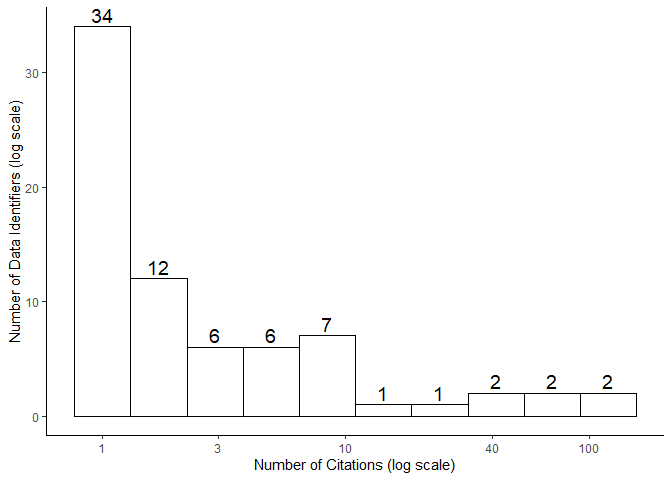

In [ ]:
#| label: fig-datasets-freq-dist
#| fig-cap: Distribution Frequency of Datasets References
#| fig-format: png

dcc_charite_joined_final |>
  group_by(charite_data_id_or_acc_nr) |>
  summarise(n = n()) |>
  ggplot(aes(x = n)) +
  geom_histogram(
    bins = 10,                  # Adjust bins to log-scaled data
    color = "black", fill = NA
  ) +
  stat_bin(
    bins = 10,                  # Same binning as histograms
    geom = "text",
    aes(label = ..count..),
    vjust = -0.3,               # Position labels above bars
    size = 5                    # Font size of labels
  ) +
  scale_x_log10(
    breaks = c(1, 3, 10, 40, 100),  # Custom breaks for the x-axis
    labels = c(1, 3, 10, 40, 100)   # Labels for x-axis
  ) +
  labs(
    x = "Number of Citations (log scale)",
    y = "Number of Data Identifiers (log scale)"
  ) +
  theme_classic()

# Distribution of References Across Repositories

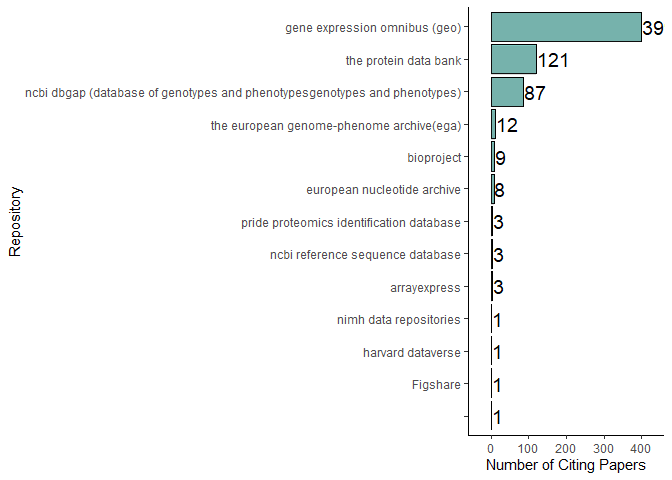

In [ ]:
#| label: fig-repo-dist
#| fig-cap: Distribution of References Across Repositories
#| fig-format: png

# Create table

rep_dt <- dcc_charite_joined_final |> 
  group_by(repository) |> 
  summarise(n = n()) |> 
  arrange(desc(n)) |> 
  mutate(repository = case_when(
    repository == "NCBI dbGaP (DataBase of Genotypes And Phenotypesgenotypes and phenotypes)" ~ "NCBI dbGaP",
    repository == "figshare" ~ "Figshare",
    repository == "The European Genome-phenome Archive(EGA)" ~ "EGA",
    repository == "Gene Expression Omnibus (GEO)" ~ "GEO",
    repository == "PRIDE Proteomics Identification Database" ~ "PRIDE",
    repository == "NCBI Reference Sequence Database" ~ "NCBI RefSeq",
    repository == "European Nucleotide Archive" ~ "ENA",
    repository == "The Protein Data Bank" ~ "PDB",
    .default = repository # shorten rep names for a nicer appearance
  ))


rep_dt |>
  ggplot(aes(x = reorder(repository, n), y = n)) +
  geom_bar(stat = "identity",
           position = "dodge",
           fill = "#80CBC4",
           color = "black") +
  geom_bar(stat = "identity", fill = "gray30",
           alpha = 0.2, position = position_nudge(x = -0.05, y = -0.1)) +  # Shadow
geom_text(aes(y = n + 2, label = n),
            vjust = 0.5,
            hjust = 0,
            size = 5, color = "black") + # text next to bars
  scale_y_continuous(expand = expansion(mult = c(0.15, 0.15))) + # Adds 5% padding on both sides of the y-axis
  coord_flip() +
  labs(x = "Repository", y = "Number of Citing Papers") +
  theme_classic()

# Datasets References by Year

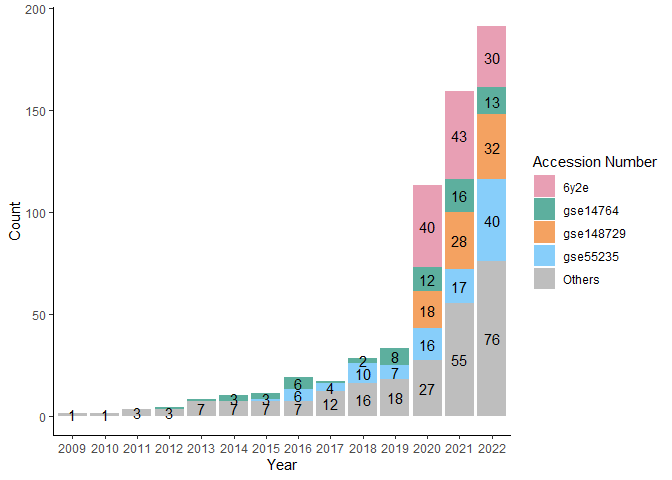

In [ ]:
#| label: fig-ref-by-year
#| fig-cap: Datasets References by Year
#| fig-format: png


# Create table

year_dcc_dt_all <- dcc_charite_joined_final |>
  select(doi_dcc, charite_data_id_or_acc_nr, publication_year_dcc) |> 
  distinct() |> 
  count(charite_data_id_or_acc_nr, sort = TRUE)

year_dcc_dt_all_for_plot <- year_dcc_dt_all |>
  inner_join(dcc_charite_joined_final, by = "charite_data_id_or_acc_nr")

year_dcc_dt_all_for_plot_agg <- year_dcc_dt_all_for_plot |> 
  mutate(charite_data_id_or_acc_nr = case_when(
    !charite_data_id_or_acc_nr %in% c("6y2e", "gse14764", "gse148729", "gse55235") ~ "Others",
    .default = charite_data_id_or_acc_nr)) |> 
  group_by(charite_data_id_or_acc_nr, publication_year_dcc) |> 
  summarise(count = n(), .groups = "drop") |> 
  dplyr::filter(publication_year_dcc != "2023")

ggplot(year_dcc_dt_all_for_plot_agg, aes(x = factor(publication_year_dcc), fill = factor(charite_data_id_or_acc_nr))) +
  geom_bar(stat = "identity",
           position = "stack",
           aes(y = count)) +
geom_text(
  data = year_dcc_dt_all_for_plot_agg |>
    group_by(publication_year_dcc) |>
    dplyr::filter(!(publication_year_dcc %in% c(2012, 2013, 2015, 2017) & count == min(count))),  # Exclude only in specific years
  aes(y = count, label = count),
  position = position_stack(vjust = 0.5)) +
  labs(
    x = "Year",
    y = "Count",
    fill = "Accession Number"
  ) +
  scale_fill_manual(values = c("#E89FB4", "#5DAF9E", "#F4A261", "#87CEFA", "grey")) +
  theme_classic() #+

# Datasets Access, Repositories and Covid-relationship

In [ ]:
#| label: fig-datasets-properties
#| fig-cap: Datasets Access, Repositories and Covid-relationship
#| fig-format: png

### temp from here! just to add data access info! delete after matching dcc and charite!
load(here("data", "processed", "charite", "charite_dois_and_ids_clean_manually_validated.RData"))


temp_access_info <- charite_dois_and_ids_clean_manually_validated |> 
  select(charite_data_id_or_acc_nr_merged, data_access) |> 
  distinct()

temp_final_with_access_info <- dcc_charite_joined_final |> 
  left_join(temp_access_info,
            by = c("charite_data_id_or_acc_nr" = "charite_data_id_or_acc_nr_merged"))
  
### end of temp! 

# Prepare table for sankey:

dcc_charite_for_sankey <- temp_final_with_access_info |>
  select(charite_data_id_or_acc_nr, data_access, covid_related, repository) |>
  distinct() |>
  mutate(acc_nr_or_doi = case_when(str_starts(charite_data_id_or_acc_nr, "10.") ~ "DOI", .default = "Accession Number"))


##### TO DO: add Blanka's datasets to the dcc_charite_for_sankey


#####

# Create a function for verifying the links df structure, extracting its entities and finally plotting it:

plot_Sankey <- function(links_df, ...) {

  # 1. Verify that all necessary col names exist
  stopifnot(all(c("source", "target", "value") %in% names(links_df)))

  # 2. Create data frame with unique values ("entities") from "source" and "target" cols
  nodes <- data.frame(
    name = c(as.character(links_df$source),
             as.character(links_df$target))  |>
      unique()
  )

  # 3. sankeyNetwork require indexing (0-based, hence the "-1") the nodes' source and target names:
  links_df$IDsource <- match(links_df$source, nodes$name) - 1
  links_df$IDtarget <- match(links_df$target, nodes$name) - 1



  # 4. Now we can insert all of our parameters into the sankeyNetwork arguments:
  sankeyNetwork(Links = links_df,
                Nodes = nodes,
                Source = "IDsource",
                Target = "IDtarget",
                Value = "value",
                NodeID = "name",
                ...)

}

# Create links data frame: accession number - data access - repository - covid

links_ac_access <- dcc_charite_for_sankey |>
  mutate(source = case_when(acc_nr_or_doi == "Accession Number" ~ "Accession Number",
                            .default = "DOI"),
         target = case_when(data_access == "yes" ~ "Full Access",
                            data_access == "restricted" ~ "Restricted Access",
                            .default = "access not checked yet")) |>
  count(source, target) |>
  rename(value = n) |>
  as.data.frame()

links_access_rep <- dcc_charite_for_sankey |>
  mutate(source = case_when(data_access == "yes" ~ "Full Access",
                            data_access == "restricted" ~ "Restricted Access",
                            .default = "access not checked yet"),
         target = case_when(
    repository == "ncbi dbgap (database of genotypes and phenotypesgenotypes and phenotypes)" ~ "NCBI dbGaP",
    repository == "figshare" ~ "figshare",
    repository == "the european genome-phenome archive(ega)" ~ "EGA",
    repository == "gene expression omnibus (gwo)" ~ "GEO",
    repository == "pride proteomics identification database" ~ "PRIDE",
    repository == "ncbi reference sequence database" ~ "NCBI RefSeq",
    repository == "european nucleotide archive" ~ "ENA",
    repository == "the protein data bank" ~ "PDB",

    .default = repository # shorten rep names for a nicer appearance
  )) |>
  count(source, target) |>
  rename(value = n) |>
  as.data.frame()

links_rep_covid <- dcc_charite_for_sankey |>
  mutate(source = case_when(
    repository == "ncbi dbgap (database of genotypes and phenotypesgenotypes and phenotypes)" ~ "NCBI dbGaP",
    repository == "figshare" ~ "figshare",
    repository == "the european genome-phenome archive(ega)" ~ "EGA",
    repository == "gene expression omnibus (gwo)" ~ "GEO",
    repository == "pride proteomics identification database" ~ "PRIDE",
    repository == "ncbi reference sequence database" ~ "NCBI RefSeq",
    repository == "european nucleotide archive" ~ "ENA",
    repository == "the protein data bank" ~ "PDB",
    .default = repository # shorten rep names for a nicer appearance
  ),
         target = case_when(covid_related == 1 ~ "Covid Related",
                            covid_related == 0 ~ "Not Covid Related",
                            .default = "covid not checked yet")) |>
  count(source, target) |>
  rename(value = n) |>
  as.data.frame()

links_all <- links_ac_access |> bind_rows(links_access_rep) |> bind_rows(links_rep_covid)

htmltools::browsable(
  plot_Sankey(links_all, sinksRight = FALSE, fontSize = 16)
)

# Datasets Access, Repositories and Covid-relationship - rep are in gray

In [ ]:
# 
# #| label: fig-datasets-properties-gray
# #| fig-cap: Datasets Access, Repositories and Covid-relationship gray
# #| fig-format: png
# 
# ### temp from here! just to add data access info! delete after matching dcc and charite!
# load(here("data", "processed", "charite", "charite_dois_and_ids_clean_manually_validated.RData"))
# 
# 
# temp_access_info <- charite_dois_and_ids_clean_manually_validated |> 
#   select(charite_data_id_or_acc_nr_merged, data_access) |> 
#   distinct()
# 
# temp_final_with_access_info <- dcc_charite_joined_final |> 
#   left_join(temp_access_info,
#             by = c("charite_data_id_or_acc_nr" = "charite_data_id_or_acc_nr_merged"))
#   
# ### end of temp! 
# 
# # Prepare table for sankey:
# 
# dcc_charite_for_sankey <- temp_final_with_access_info |>
#   select(charite_data_id_or_acc_nr, data_access, covid_related, repository) |>
#   distinct() |>
#   mutate(acc_nr_or_doi = case_when(str_starts(charite_data_id_or_acc_nr, "10.") ~ "DOI", .default = "Accession Number"))
# 
# 
# ##### TO DO: add Blanka's datasets to the dcc_charite_for_sankey
# 
# 
# #####
# 
# # Create a function for verifying the links df structure, extracting its entities and finally plotting it:
# 
# plot_Sankey <- function(links_df, ...) {
# 
#   # 1. Verify required columns
#   stopifnot(all(c("source", "target", "value") %in% names(links_df)))
# 
#   # 2. Unique nodes
#   nodes <- data.frame(
#     name = c(as.character(links_df$source), as.character(links_df$target)) |> unique()
#   )
# 
#   # 3. Add repository-level detection logic
#   repository_nodes <- intersect(links_access_rep$target, links_rep_covid$source)
# # Filter: repository-level nodes ONLY
# repository_nodes_clean <- setdiff(repository_nodes, c("DOI", "Accession Number"))
# 
# nodes$group <- ifelse(nodes$name %in% repository_nodes_clean, "repository", nodes$name)
# 
# 
#   # Manually define colors per node or group
# color_map <- c(
#   "repository" = "#888888",         # shared gray for all repositories
#   "Accession Number" = "#1f77b4",
#   "DOI" = "#ff7f0e",
#   "Full Access" = "#2ca02c",
#   "Restricted Access" = "#d62728",
#   "access not checked yet" = "#9467bd",
#   "NCBI dbGaP" = "#8c564b",
#   "figshare" = "#e377c2",
#   "EGA" = "#7f7f7f",
#   "GEO" = "#bcbd22",
#   "PRIDE" = "#17becf",
#   "NCBI RefSeq" = "#aec7e8",
#   "ENA" = "#ffbb78",
#   "PDB" = "#98df8a",
#   "Covid Related" = "#c5b0d5",
#   "Not Covid Related" = "#f7b6d2",
#   "covid not checked yet" = "#c49c94"
# )
# 
#   
#   # 4. Add indexing columns to links
#   links_df$IDsource <- match(links_df$source, nodes$name) - 1
#   links_df$IDtarget <- match(links_df$target, nodes$name) - 1
# 
#   # # 5. Build custom colour scale string
#   # unique_groups <- unique(nodes$group)
#   # palette <- c("#888888", brewer.pal(n = length(unique_groups) - 1, name = "Set3"))
#   # color_map <- setNames(palette, unique_groups)
# 
#   colourScale_str <- paste0(
#     "d3.scaleOrdinal().domain([",
#     paste0("'", names(color_map), "'", collapse = ", "),
#     "]).range([",
#     paste0("'", color_map, "'", collapse = ", "),
#     "])")
# 
#   # 6. Sankey plot
#   sankeyNetwork(
#     Links = links_df,
#     Nodes = nodes,
#     Source = "IDsource",
#     Target = "IDtarget",
#     Value = "value",
#     NodeID = "name",
#     NodeGroup = "group",
#     colourScale = JS(colourScale_str),
#     ...
#   )
# }
# 
# # Combine all links
# dcc_charite_for_sankey <- dcc_charite_for_sankey  # in case it's not in scope yet
# 
# links_ac_access <- dcc_charite_for_sankey |>
#   mutate(source = case_when(acc_nr_or_doi == "Accession Number" ~ "Accession Number",
#                             .default = "DOI"),
#          target = case_when(data_access == "yes" ~ "Full Access",
#                             data_access == "restricted" ~ "Restricted Access",
#                             .default = "access not checked yet")) |>
#   count(source, target) |>
#   rename(value = n) |>
#   as.data.frame()
# 
# links_access_rep <- dcc_charite_for_sankey |>
#   mutate(source = case_when(data_access == "yes" ~ "Full Access",
#                             data_access == "restricted" ~ "Restricted Access",
#                             .default = "access not checked yet"),
#          target = case_when(
#            repository == "ncbi dbgap (database of genotypes and phenotypesgenotypes and phenotypes)" ~ "NCBI dbGaP",
#            repository == "figshare" ~ "figshare",
#            repository == "the european genome-phenome archive(ega)" ~ "EGA",
#            repository == "gene expression omnibus (gwo)" ~ "GEO",
#            repository == "pride proteomics identification database" ~ "PRIDE",
#            repository == "ncbi reference sequence database" ~ "NCBI RefSeq",
#            repository == "european nucleotide archive" ~ "ENA",
#            repository == "the protein data bank" ~ "PDB",
#            .default = repository)) |>
#   count(source, target) |>
#   rename(value = n) |>
#   as.data.frame()
# 
# links_rep_covid <- dcc_charite_for_sankey |>
#   mutate(source = case_when(
#            repository == "ncbi dbgap (database of genotypes and phenotypesgenotypes and phenotypes)" ~ "NCBI dbGaP",
#            repository == "figshare" ~ "figshare",
#            repository == "the european genome-phenome archive(ega)" ~ "EGA",
#            repository == "gene expression omnibus (gwo)" ~ "GEO",
#            repository == "pride proteomics identification database" ~ "PRIDE",
#            repository == "ncbi reference sequence database" ~ "NCBI RefSeq",
#            repository == "european nucleotide archive" ~ "ENA",
#            repository == "the protein data bank" ~ "PDB",
#            .default = repository),
#          target = case_when(covid_related == 1 ~ "Covid Related",
#                             covid_related == 0 ~ "Not Covid Related",
#                             .default = "covid not checked yet")) |>
#   count(source, target) |>
#   rename(value = n) |>
#   as.data.frame()
# 
# links_all <- bind_rows(links_ac_access, links_access_rep, links_rep_covid)
# 
# # Plot
# plot_Sankey(links_all, sinksRight = FALSE, fontSize = 16)

# Datasets and Citing Papers Publication Years

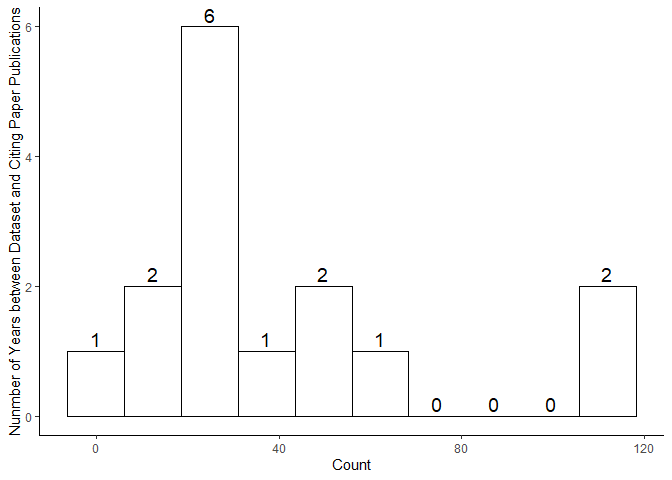

In [ ]:
#| label: fig-datasets-and-papers-years
#| fig-cap: Datasets and Citing Papers Publication Years
#| fig-format: png

# Create table

dif_for_plot <- dcc_charite_joined_final |>
  select(doi_charite, doi_dcc, publication_year_dcc, dataset_publication_year) |> 
  distinct() |> 
  mutate(dif = publication_year_dcc - dataset_publication_year) |>
  group_by(dif) |> 
  summarise(n = n())

# Plot

dif_for_plot |>
  dplyr::filter(dif >= 0) |> 
  ggplot(aes(x = n)) +
  geom_histogram(
    bins = 10,                  # Adjust bins to log-scaled data
    color = "black", fill = NA
  ) +
  stat_bin(
    bins = 10,                  # Same binning as histograms
    geom = "text",
    aes(label = ..count..),
    vjust = -0.3,               # Position labels above bars
    size = 5                    # Font size of labels
  ) +
  # scale_x_log10(
  #   breaks = c(1, 3, 10, 40, 100),  # Custom breaks for the x-axis
  #   labels = c(1, 3, 10, 40, 100)   # Labels for x-axis
  # ) +
  labs(
    x = "Count",
    y = "Nunmber of Years between Dataset and Citing Paper Publications"
  ) +
  theme_classic()